# NB04b - PCA with Half Window (WIN=50)

Fork of NB 04 with **only the window length halved**: `WIN = 50` instead of `WIN = 100`.

**Motivation.** NB 04's ceiling is 17 missed events on val; roughly half of them are short
(< 1000 rows). A 30-row anomaly gets only 30 % weight inside a 100-row window-mean — signal
is diluted. Halving the window doubles the weight of short events (30/50 = 60 %) while
keeping the flat-MSE aggregation that transfers well to Kaggle (test-score-range stays in
the narrow band the val-tuned threshold lives in).

**What is kept identical to NB 04:**
- Flat MSE aggregation (`((batch - rec)**2).mean(axis=1)`) — same score-distribution shape
- Non-overlapping windows (stride = WIN)
- PCA fit on random 50k nominal windows, `n_components = k_95`
- ESA-corrected event-wise F0.5 threshold sweep
- 80/20 temporal val split (`SPLIT_IDX = 11_782_656`)

**What changes:** `WIN = 50` (so flattened window dim is `50 × 58 = 2900`). `k_95` is refit
from the new fit data; expected to land around 20–25.

**Output:** `submissions/04b_pca_win50.parquet`

**Go/No-Go on val:**
- `val F0.5 > 0.770` AND `fp_pred_events == 0` → submit
- Otherwise → back off to WIN=75 or abandon


## 0 - Setup & Imports

In [1]:
import sys, gc, json, time
sys.path.insert(0, '../src')
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
import pickle

from sentinel.ml_logic.data import find_anomaly_segments
from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR, RANDOM_STATE, FIT_SIZE

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR   = Path('../data/processed/kaggle')
MODELS_DIR      = Path('../models')
SUBMISSIONS_DIR = Path('../submissions')
MODELS_DIR.mkdir(exist_ok=True)
SUBMISSIONS_DIR.mkdir(exist_ok=True)

print('Setup complete.')


Setup complete.


---
## 1 - Load Data  (WIN override)

In [2]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

SPLIT_IDX  = cfg['split_idx']     # 11_782_656
N_FEAT     = cfg['n_features']    # 58
WIN        = 50                   # ← experiment: halve window length
WIN_FLAT   = WIN * N_FEAT         # 2_900

print('Loading arrays …')
t0 = time.time()
X_train_nom_100 = np.load(PROCESSED_DIR / 'X_train_nom.npy')   # (N_win100, 100, 58)
X_all           = np.load(PROCESSED_DIR / 'train_full_scaled.npy')
y_all           = np.load(PROCESSED_DIR / 'y_train_row.npy')
X_test          = np.load(PROCESSED_DIR / 'test_scaled.npy')
test_ids        = np.load(PROCESSED_DIR / 'test_ids.npy')
print(f'  loaded in {time.time()-t0:.1f}s')

# Split each 100-row nominal window into two 50-row windows.
# Valid because X_train_nom was built from contiguous nominal rows, so each 100-row
# block is fully nominal — both 50-row halves are nominal too.
N100 = X_train_nom_100.shape[0]
X_train_nom = X_train_nom_100.reshape(N100 * 2, WIN, N_FEAT)
del X_train_nom_100; gc.collect()
print(f'  X_train_nom (WIN={WIN}): {X_train_nom.shape}   ({X_train_nom.shape[0]:,} windows)')
print(f'  X_all                  : {X_all.shape}')
print(f'  X_test                 : {X_test.shape}')
print(f'  WIN={WIN}  N_FEAT={N_FEAT}  WIN_FLAT={WIN_FLAT}')


Loading arrays …


  loaded in 1.5s
  X_train_nom (WIN=50): (210974, 50, 58)   (210,974 windows)
  X_all                  : (14728321, 58)
  X_test                 : (521280, 58)
  WIN=50  N_FEAT=58  WIN_FLAT=2900


In [3]:
X_val = X_all[SPLIT_IDX:]
y_val = y_all[SPLIT_IDX:]
del X_all, y_all; gc.collect()

val_segments = find_anomaly_segments(y_val)
n_events     = len(val_segments)
n_nom_val    = int((y_val == 0).sum())
nom_mask_val = (y_val == 0)

print(f'Val rows          : {len(X_val):,}  ({int(y_val.sum()):,} anomalous)')
print(f'Val anomaly events: {n_events}')
print(f'Val nominal rows  : {n_nom_val:,}')


Val rows          : 2,945,665  (310,175 anomalous)
Val anomaly events: 38
Val nominal rows  : 2,635,490


---
## 2 - Fit PCA on 50-row Nominal Windows

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
fit_idx = rng.choice(len(X_train_nom), size=FIT_SIZE, replace=False)
X_fit   = X_train_nom[fit_idx].reshape(FIT_SIZE, WIN_FLAT)
del X_train_nom; gc.collect()

print(f'Fitting full PCA on {X_fit.shape[0]:,} nominal 50-row windows …')
t0 = time.time()
pca_full = PCA(n_components=None, random_state=RANDOM_STATE).fit(X_fit)
print(f'  fit in {time.time()-t0:.1f}s')

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
k_90 = int(np.searchsorted(cum_var, 0.90)) + 1
k_95 = int(np.searchsorted(cum_var, 0.95)) + 1
k_99 = int(np.searchsorted(cum_var, 0.99)) + 1
print(f'  Components for 90% variance: {k_90}')
print(f'  Components for 95% variance: {k_95}')
print(f'  Components for 99% variance: {k_99}')

N_COMPONENTS = k_95
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE).fit(X_fit)
print(f'  refit  n_components={N_COMPONENTS}  explained var={pca.explained_variance_ratio_.sum()*100:.2f}%')

ts = time.strftime('%Y%m%d_%H%M%S')
model_path = MODELS_DIR / f'pca_04b_win50_{ts}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(pca, f)
del X_fit; gc.collect()
print(f'  model saved → {model_path}')


Fitting full PCA on 50,000 nominal 50-row windows …


  fit in 10.9s
  Components for 90% variance: 14
  Components for 95% variance: 33
  Components for 99% variance: 386


  refit  n_components=33  explained var=95.07%
  model saved → ../models/pca_04b_win50_20260424_142421.pkl


---
## 3 - Scoring: Non-overlapping 50-row Windows, Flat MSE (NB-04 style)

Exact same recipe as NB 04, just with `win = 50`:
- one MSE per 50-row window (mean over all 2900 residuals)
- broadcast that score to all 50 rows in the window


In [5]:
def score_windows(model, X_rows, win=50, n_feat=58, batch_windows=5000):
    """
    NB-04-style scoring with configurable window length.
    Non-overlapping stride=win, flat MSE, broadcast to rows.
    """
    N, nf = X_rows.shape
    assert nf == n_feat
    n_complete = N // win
    flat_dim   = win * n_feat
    win_scores = np.empty(n_complete, dtype=np.float32)

    for batch_start in range(0, n_complete, batch_windows):
        batch_end = min(batch_start + batch_windows, n_complete)
        batch = np.stack([
            X_rows[i*win:(i+1)*win].reshape(flat_dim)
            for i in range(batch_start, batch_end)
        ])
        rec  = model.inverse_transform(model.transform(batch))
        win_scores[batch_start:batch_end] = ((batch - rec) ** 2).mean(axis=1)

    scores_row = np.zeros(N, dtype=np.float32)
    for i in range(n_complete):
        scores_row[i*win:(i+1)*win] = win_scores[i]
    if n_complete * win < N:
        scores_row[n_complete*win:] = win_scores[-1] if n_complete > 0 else 0.0
    return scores_row, win_scores


print(f'Scoring val set ({len(X_val):,} rows)  win={WIN} …')
t0 = time.time()
scores_val, win_scores_val = score_windows(pca, X_val, win=WIN, n_feat=N_FEAT)
print(f'  done in {time.time()-t0:.1f}s')
print(f'  n windows    : {len(win_scores_val):,}')
print(f'  row scores   : [{scores_val.min():.6f}, {scores_val.max():.6f}]')
print(f'  mean nominal : {scores_val[y_val==0].mean():.6f}')
print(f'  mean anomaly : {scores_val[y_val==1].mean():.6f}')


Scoring val set (2,945,665 rows)  win=50 …


  done in 1.0s
  n windows    : 58,913
  row scores   : [0.013455, 2344.416992]
  mean nominal : 0.075297
  mean anomaly : 0.626259


### Score distribution: nominal vs anomaly

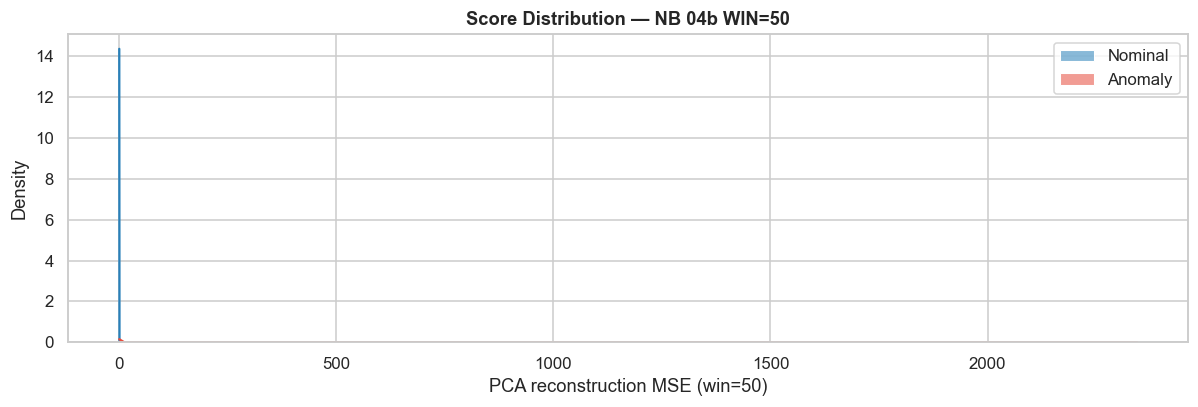

ROC-AUC (row-level): 0.7125


In [6]:
nom_scores  = scores_val[y_val == 0]
anom_scores = scores_val[y_val == 1]
NSAMP = 100_000
rng2  = np.random.default_rng(RANDOM_STATE + 1)
nom_s  = rng2.choice(nom_scores,  size=min(NSAMP, len(nom_scores)),  replace=False)
anom_s = rng2.choice(anom_scores, size=min(NSAMP, len(anom_scores)), replace=False)

fig, ax = plt.subplots(figsize=(11, 3.8))
sns.histplot(nom_s,  ax=ax, color=NOMINAL_COLOR, alpha=0.55, bins=80,
             stat='density', kde=True, label='Nominal')
sns.histplot(anom_s, ax=ax, color=ANOMALY_COLOR, alpha=0.55, bins=80,
             stat='density', kde=True, label='Anomaly')
ax.set_xlabel(f'PCA reconstruction MSE (win={WIN})')
ax.set_ylabel('Density')
ax.set_title(f'Score Distribution — NB 04b WIN={WIN}', fontweight='bold')
ax.legend()
fig.tight_layout(); plt.show()

from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_val, scores_val)
print(f'ROC-AUC (row-level): {auc:.4f}')


---
## 4 - Threshold Tuning on Corrected Event-Wise F0.5

In [7]:
gt_cumsum = np.concatenate([[0], np.cumsum((y_val == 1).astype(np.int32))])
seg_max_scores = np.array(
    [scores_val[s['start']:s['end']+1].max() for s in val_segments],
    dtype=np.float32,
)

thresholds = np.linspace(
    np.percentile(scores_val, 0.5),
    np.percentile(scores_val, 99.9),
    num=400,
)

results = []
for thr in thresholds:
    pred = (scores_val >= thr).astype(np.int8)
    tp = int((seg_max_scores >= thr).sum())
    fn = n_events - tp
    padded = np.concatenate([[0], pred, [0]])
    d      = np.diff(padded)
    starts_pred = np.where(d ==  1)[0]
    ends_pred   = np.where(d == -1)[0] - 1
    fp_pred_ev  = int(((gt_cumsum[ends_pred+1] - gt_cumsum[starts_pred]) == 0).sum()) if len(starts_pred) > 0 else 0
    fp_samples  = int(((scores_val >= thr) & nom_mask_val).sum())
    tnr         = max(0.0, 1.0 - fp_samples / n_nom_val) if n_nom_val > 0 else 1.0
    denom_pr    = tp + fp_pred_ev
    pr_ew       = tp / denom_pr if denom_pr > 0 else 0.0
    precision   = pr_ew * tnr
    recall      = tp / n_events if n_events > 0 else 0.0
    f05         = (1.25 * precision * recall / (0.25 * precision + recall)
                   if (precision + recall) > 0 else 0.0)
    results.append({
        'threshold':float(thr),'f05':f05,'precision':precision,'recall':recall,
        'tp_events':tp,'fn_events':fn,'fp_pred_events':fp_pred_ev,
        'fp_samples':fp_samples,'tnr':tnr,'n_predicted':int(pred.sum()),
        'pos_rate':pred.mean(),
    })

res_df = pd.DataFrame(results)
best   = res_df.loc[res_df['f05'].idxmax()]
print(f'Sweep done ({len(thresholds)} thresholds).\n')
print('=== Best threshold (corrected event-wise F0.5) ===')
for col in ['threshold','f05','precision','recall','tp_events','fn_events',
            'fp_pred_events','fp_samples','tnr','n_predicted','pos_rate']:
    print(f'  {col:<16}: {best[col]}')

print()
print(f'NB 04 reference: F0.5=0.770, 21/38 events, fp_pred_events=0, pos_rate=18.08%')
print(f'Go condition:    F0.5 > 0.770  AND  fp_pred_events == 0')


Sweep done (400 thresholds).

=== Best threshold (corrected event-wise F0.5) ===
  threshold       : 0.12446052567067002
  f05             : 0.7705382779354306
  precision       : 0.8548019533369506
  recall          : 0.5526315789473685
  tp_events       : 21.0
  fn_events       : 17.0
  fp_pred_events  : 0.0
  fp_samples      : 382668.0
  tnr             : 0.8548019533369506
  n_predicted     : 531515.0
  pos_rate        : 0.18043973092663287

NB 04 reference: F0.5=0.770, 21/38 events, fp_pred_events=0, pos_rate=18.08%
Go condition:    F0.5 > 0.770  AND  fp_pred_events == 0


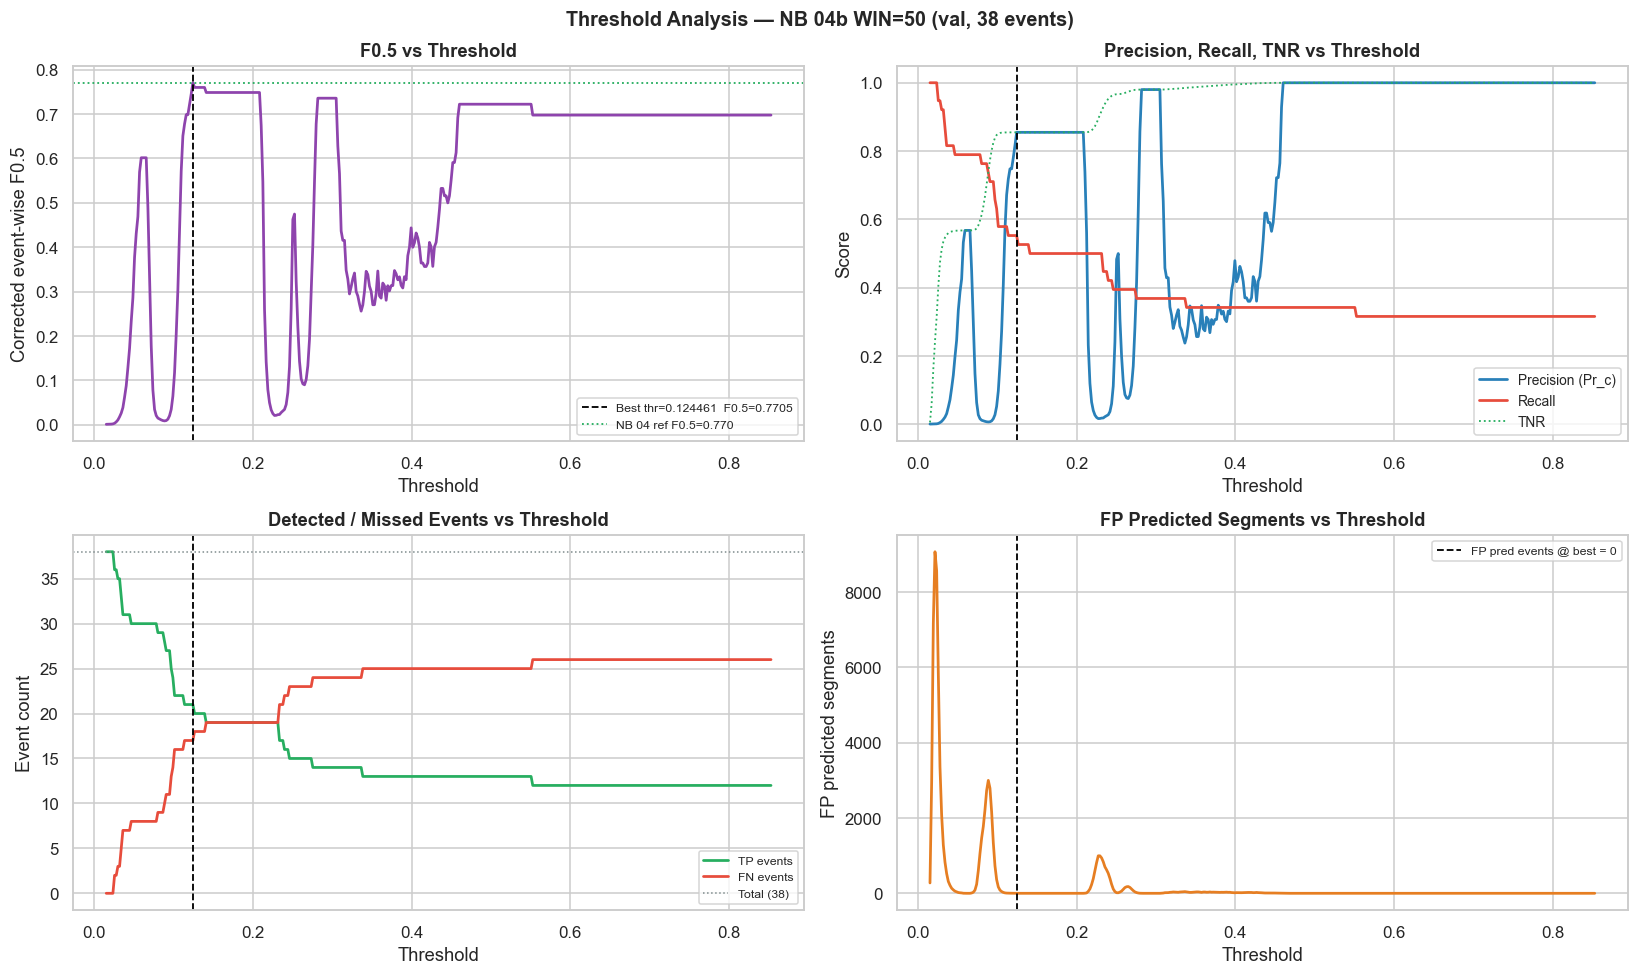

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

ax = axes[0, 0]
ax.plot(res_df['threshold'], res_df['f05'], color='#8e44ad', lw=1.8)
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2,
           label=f'Best thr={best["threshold"]:.6f}  F0.5={best["f05"]:.4f}')
ax.axhline(0.770, color='#27ae60', ls=':', lw=1.2, label='NB 04 ref F0.5=0.770')
ax.set_xlabel('Threshold'); ax.set_ylabel('Corrected event-wise F0.5')
ax.set_title('F0.5 vs Threshold', fontweight='bold'); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(res_df['threshold'], res_df['precision'], color=NOMINAL_COLOR, lw=1.8, label='Precision (Pr_c)')
ax.plot(res_df['threshold'], res_df['recall'],    color=ANOMALY_COLOR, lw=1.8, label='Recall')
ax.plot(res_df['threshold'], res_df['tnr'],       color='#27ae60',     lw=1.2, ls=':', label='TNR')
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Precision, Recall, TNR vs Threshold', fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(-0.05, 1.05)

ax = axes[1, 0]
ax.plot(res_df['threshold'], res_df['tp_events'], color='#27ae60', lw=1.8, label='TP events')
ax.plot(res_df['threshold'], res_df['fn_events'], color=ANOMALY_COLOR, lw=1.8, label='FN events')
ax.axhline(n_events, color='#7f8c8d', ls=':', lw=1, label=f'Total ({n_events})')
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2)
ax.set_xlabel('Threshold'); ax.set_ylabel('Event count')
ax.set_title('Detected / Missed Events vs Threshold', fontweight='bold'); ax.legend(fontsize=8)

ax = axes[1, 1]
ax.plot(res_df['threshold'], res_df['fp_pred_events'], color='#e67e22', lw=1.8)
ax.axvline(best['threshold'], color='black', ls='--', lw=1.2,
           label=f'FP pred events @ best = {int(best["fp_pred_events"])}')
ax.set_xlabel('Threshold'); ax.set_ylabel('FP predicted segments')
ax.set_title('FP Predicted Segments vs Threshold', fontweight='bold'); ax.legend(fontsize=8)

fig.suptitle(f'Threshold Analysis — NB 04b WIN={WIN} (val, {n_events} events)',
             fontsize=13, fontweight='bold')
fig.tight_layout(); plt.show()


---
## 5 - Per-Event Analysis — which short events did WIN=50 rescue?

In [9]:
BEST_THR = float(best['threshold'])
y_pred_val = (scores_val >= BEST_THR).astype(np.int8)

event_rows = []
for seg in val_segments:
    pred_in_seg = y_pred_val[seg['start']:seg['end']+1]
    n_det = int(pred_in_seg.sum())
    event_rows.append({
        'start':seg['start'],'end':seg['end'],'length':seg['length'],
        'detected': n_det > 0, 'n_pred_in_seg': n_det,
        'hit_rate': n_det / seg['length'],
    })
event_df = pd.DataFrame(event_rows)
n_detected = int(event_df['detected'].sum())
n_missed   = n_events - n_detected

# NB 04 missed events (for comparison)
NB04_MISSED_STARTS = {
    83329, 108656, 439490, 439987, 444730, 537037, 596442, 733020, 1159843,
    1402963, 1639976, 1821040, 1854929, 1855565, 1857081, 1857719, 2222931,
}

print(f'Events detected : {n_detected} / {n_events}   (NB 04: 21 / 38)')
print(f'Events missed   : {n_missed}')
print()

# Short events (<1000) that NB 04 missed — did WIN=50 rescue any?
short_nb04_missed = event_df[
    event_df['start'].isin(NB04_MISSED_STARTS) & (event_df['length'] < 1000)
]
rescued = short_nb04_missed[short_nb04_missed['detected']]
still_missed = short_nb04_missed[~short_nb04_missed['detected']]

print(f'Short NB-04-missed events (<1000 rows):  {len(short_nb04_missed)}')
print(f'  → rescued by WIN=50:   {len(rescued)}')
print(f'  → still missed:        {len(still_missed)}')
if len(rescued) > 0:
    print('\nRescued short events:')
    print(rescued[['start','end','length','hit_rate']].to_string(index=False))

if n_missed > 0:
    print('\nAll missed events (04b WIN=50):')
    print(event_df[~event_df['detected']][['start','end','length']].to_string(index=False))


Events detected : 21 / 38   (NB 04: 21 / 38)
Events missed   : 17

Short NB-04-missed events (<1000 rows):  9
  → rescued by WIN=50:   0
  → still missed:        9

All missed events (04b WIN=50):
  start     end  length
  83329   83604     276
 108656  140544   31889
 439490  439676     187
 439987  441096    1110
 444730  445395     666
 537037  537315     279
 596442  597691    1250
 733020  759444   26425
1159843 1161322    1480
1402963 1408098    5136
1639976 1644667    4692
1821040 1833984   12945
1854929 1854960      32
1855565 1855591      27
1857081 1857103      23
1857719 1857748      30
2222931 2223641     711


---
## 6 - Generate Test Predictions & Submission

In [10]:
print(f'Scoring test ({len(X_test):,} rows)  win={WIN} …')
t0 = time.time()
scores_test, win_scores_test = score_windows(pca, X_test, win=WIN, n_feat=N_FEAT)
print(f'  done in {time.time()-t0:.1f}s')
print(f'  test score range : [{scores_test.min():.6f}, {scores_test.max():.6f}]')
print(f'  val  score range : [{scores_val.min():.6f}, {scores_val.max():.6f}]')
print(f'  threshold        : {BEST_THR:.6f}')

y_pred_test = (scores_test >= BEST_THR).astype(np.uint8)
pct_flagged = y_pred_test.mean() * 100
print(f'  test flagged     : {y_pred_test.sum():,} / {len(y_pred_test):,} ({pct_flagged:.2f}%)')


Scoring test (521,280 rows)  win=50 …
  done in 0.1s
  test score range : [0.055598, 2.564575]
  val  score range : [0.013455, 2344.416992]
  threshold        : 0.124461
  test flagged     : 33,850 / 521,280 (6.49%)


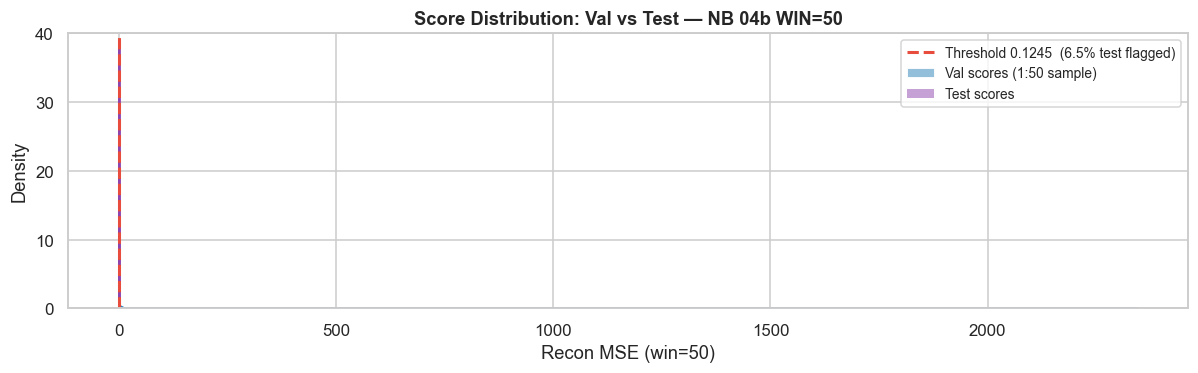

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.5))
sns.histplot(scores_val[::50], bins=100, ax=ax, color=NOMINAL_COLOR, alpha=0.5,
             stat='density', kde=True, label='Val scores (1:50 sample)')
sns.histplot(scores_test, bins=100, ax=ax, color='#8e44ad', alpha=0.5,
             stat='density', kde=True, label='Test scores')
ax.axvline(BEST_THR, color=ANOMALY_COLOR, lw=2, ls='--',
           label=f'Threshold {BEST_THR:.4f}  ({pct_flagged:.1f}% test flagged)')
ax.set_xlabel(f'Recon MSE (win={WIN})'); ax.set_ylabel('Density')
ax.set_title(f'Score Distribution: Val vs Test — NB 04b WIN={WIN}', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()


---
## Timeline — Val + Test

Standardized two-panel plot via `plot_timeline(scores, y_true, threshold, ..., log_y=True)`. Use `index` to switch the x-axis from split-local positions (default) to absolute dataset indices.

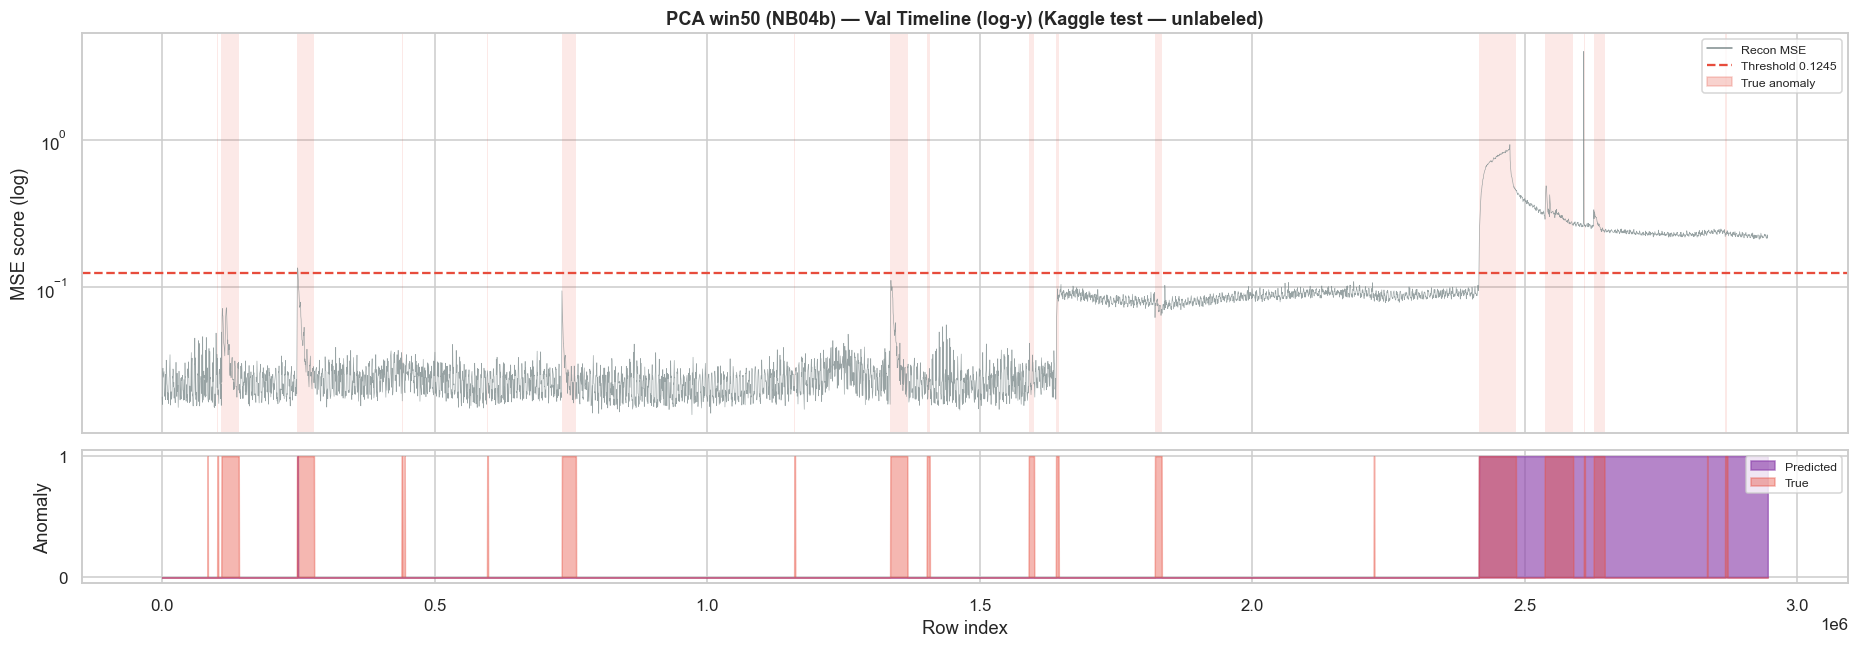

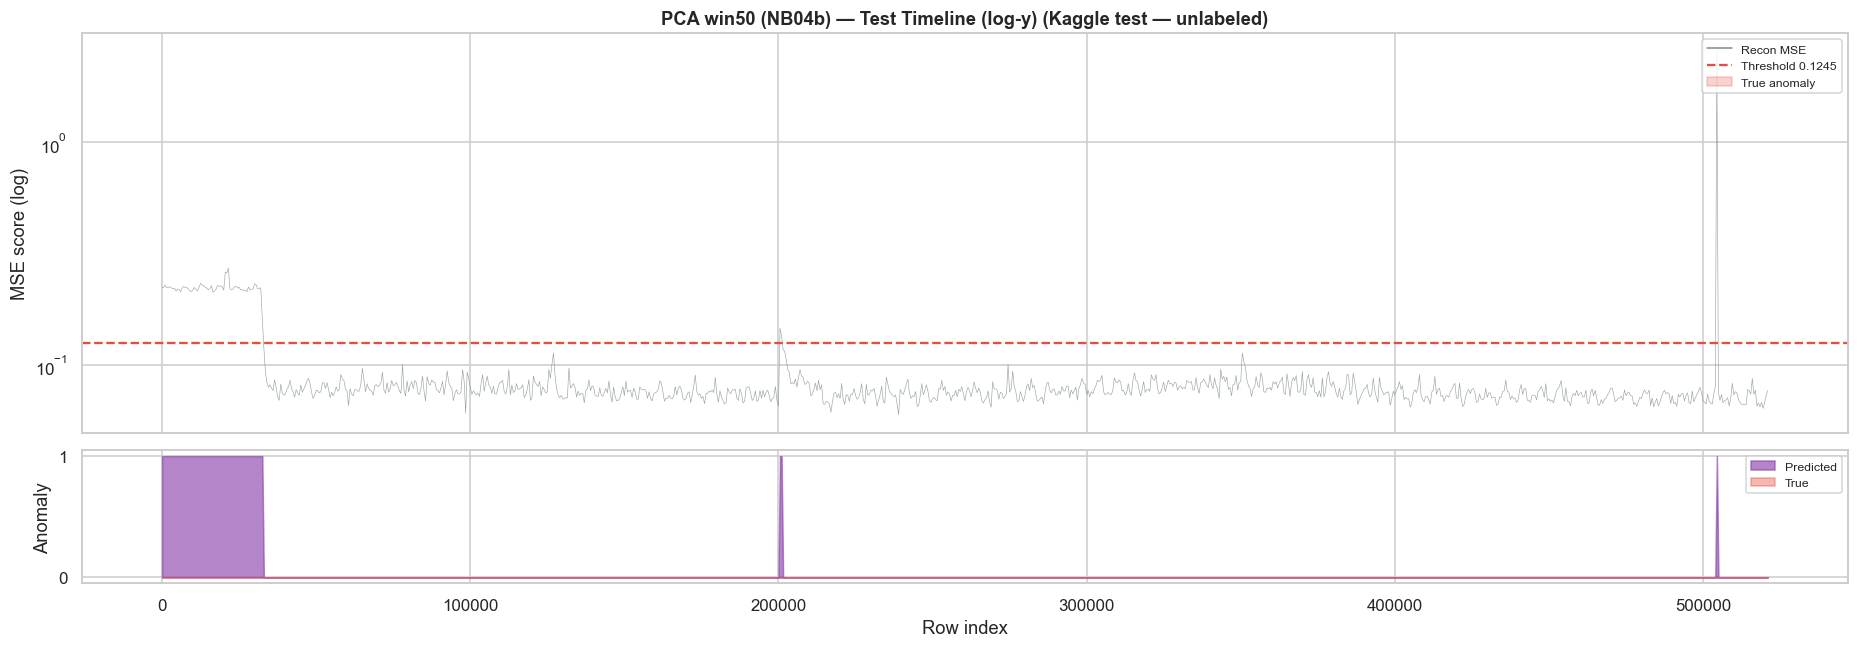

In [12]:
from sentinel.ml_logic.viz import plot_timeline

MODEL_NAME = 'PCA win50 (NB04b)'

_ = plot_timeline(scores_val, y_val, BEST_THR,
                  f'{MODEL_NAME} — Val Timeline (log-y) (Kaggle test — unlabeled)', log_y=True)
plt.show(); plt.close()

_ = plot_timeline(scores_test, np.zeros(len(scores_test), dtype=np.int8), BEST_THR,
                  f'{MODEL_NAME} — Test Timeline (log-y) (Kaggle test — unlabeled)', log_y=True)
plt.show(); plt.close()

In [13]:
# ── Save model ──────────────────────────────────────────────────────────
# # Save model
# import time
# ts = time.strftime('%Y%m%d_%H%M%S')
# with open(MODELS_DIR / f'pca_nb04b_{ts}.pkl', 'wb') as f:
#     pickle.dump(pca_full, f)
# print(f'  model saved → models/pca_nb04b_{ts}.pkl')


In [14]:
# Save scores — nach Review auskommentieren und ausführen
# SCORES_DIR = PROCESSED_DIR / 'scores'
# SCORES_DIR.mkdir(parents=True, exist_ok=True)
# np.save(SCORES_DIR / 'scores_val_pca_nb04b.npy',  scores_val)
# np.save(SCORES_DIR / 'scores_test_pca_nb04b.npy', scores_test)
# print(f'Scores saved → {SCORES_DIR}/scores_{{val,test}}_pca_nb04b.npy')


In [15]:
# ── Kaggle submission ───────────────────────────────────────────────────
# submission = pd.DataFrame({'id': test_ids, 'is_anomaly': y_pred_test})
#
# sample_sub = pd.read_parquet('../data/raw/sample_submission.parquet')
# assert list(submission['id']) == list(sample_sub['id']), 'ID mismatch vs sample submission!'
# print('ID alignment: ✓')
#
# ts = time.strftime('%Y%m%d_%H%M%S')
# submission_path = SUBMISSIONS_DIR / f'pca_nb04b_{ts}.parquet'
# submission.to_parquet(submission_path, index=False)
# print(f'Submission saved → {submission_path}')
# print(submission.head())
# print(f'Anomaly rows: {submission["is_anomaly"].sum():,} ({submission["is_anomaly"].mean()*100:.2f}%)')
#


---
## Summary

| Setting | Value |
|---|---|
| Window | **50** (non-overlapping, stride=50) |
| Aggregation | flat MSE over 2900 residuals |
| PCA fit | random 50k of ~211k nominal 50-row windows |
| `n_components` | `k_95` (expected ≈ 20–25) |
| Threshold metric | corrected event-wise F0.5 |
| Submission | `submissions/04b_pca_win50.parquet` |

**Expected vs NB 04 (0.522 / 0.599):**
- Short events (<1000 rows) lift in score → **recall should rise above 21/38**.
- Flat-MSE shape preserved → val→test score range should stay narrow → threshold transfers.
- Risk: 2× more windows → more chances of random nominal spike crossing threshold → watch
  `fp_pred_events` at best thr and test `pos_rate`.
- **Submit only if** val F0.5 > 0.770 AND fp_pred_events == 0 at best thr AND test
  `pos_rate` within 3–10 %.
